In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from jax.random import split, key

from binary import get_binary

%load_ext autoreload
%autoreload 2

/n/home03/newolfe/.conda/envs/seqpop/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
@jax.jit
def get_pop(sigma_kick, n=1_000_000):
    """ sigma_kick in km / s """
    parameters = dict(
        mbhmax=45,
        mturnover=35,
        sigma_mbh=0,
        alpha_prog_1=2.0,
        alpha_prog_2=1.1,
        prog_mmin=3,
        prog_mmax=80,
        prog_break_mass=20,
        sigma_kick=sigma_kick,
        align_a_post_sn1=False,
        align_b_post_sn1=False,
    )

    return jax.vmap(
        lambda k: get_binary(k, parameters)
    )(split(key(2), n))

In [3]:
from jax_tqdm import scan_tqdm

nsigma = 50
sigmas = jnp.logspace(1, 4, nsigma)

@scan_tqdm(nsigma, desc='Generating populations')
def step(carry, x):
    _, sigma = x
    return carry, get_pop(sigma)

_, pops = jax.lax.scan(step, None, (jnp.arange(nsigma), sigmas))

Generating populations: 100%|██████████| 50/50 [00:00<00:00, 309.42it/s]


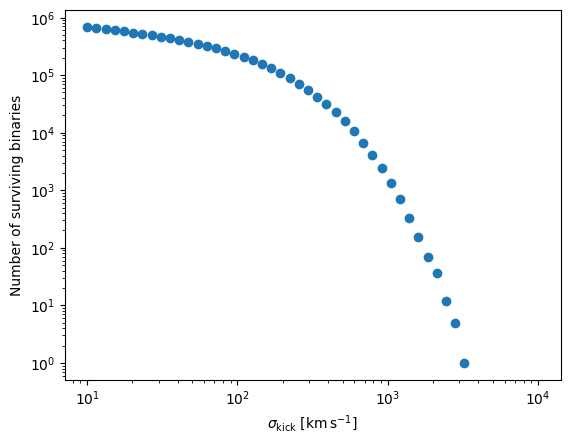

In [4]:
fig, ax = plt.subplots()
ax.scatter(
    sigmas,
    jnp.sum(pops['survive'], axis=-1),
)
ax.loglog();
ax.set_ylabel('Number of surviving binaries')
ax.set_xlabel(r'$\sigma_{\rm kick}$ [$\mathrm{km} \, \mathrm{s}^{-1}$]')
fig.savefig('../../notes/figures/26-01-02/survival.png')

In [8]:
def get_pop(sigma_kick, align_a=False, align_b=False, n=1_000_000):
    """ sigma_kick in km / s """
    parameters = dict(
        mbhmax=45,
        mturnover=35,
        sigma_mbh=0,
        alpha_prog_1=2.0,
        alpha_prog_2=1.1,
        prog_mmin=8,
        prog_mmax=80,
        prog_break_mass=20,
        sigma_kick=sigma_kick,
        align_a_post_sn1=align_a,
        align_b_post_sn1=align_b,
    )

    return jax.vmap(
        lambda k: get_binary(k, parameters)
    )(split(key(2), n))

In [9]:
from jax_tqdm import scan_tqdm

nsigma = 10
sigmas = jnp.logspace(1, 3, nsigma)

@scan_tqdm(nsigma, desc='Generating populations')
def step(carry, x):
    _, sigma = x
    return carry, get_pop(sigma)

_, pops_no_realign = jax.lax.scan(step, None, (jnp.arange(nsigma), sigmas))

Generating populations: 100%|██████████| 10/10 [00:00<00:00, 323.57it/s]


In [10]:
@scan_tqdm(nsigma, desc='Generating populations')
def step(carry, x):
    _, sigma = x
    return carry, get_pop(sigma, align_a=True)

_, pops_realign_a = jax.lax.scan(step, None, (jnp.arange(nsigma), sigmas))

Generating populations: 100%|██████████| 10/10 [00:00<00:00, 325.46it/s]


In [11]:
@scan_tqdm(nsigma, desc='Generating populations')
def step(carry, x):
    _, sigma = x
    return carry, get_pop(sigma, align_a=True, align_b=True)

_, pops_realign_both = jax.lax.scan(step, None, (jnp.arange(nsigma), sigmas))

Generating populations: 100%|██████████| 10/10 [00:00<00:00, 335.47it/s]


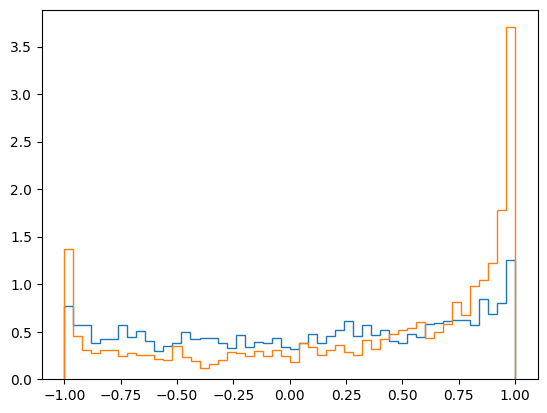

In [25]:
bins = 50 #np.linspace(-1, 1, 50)
ks = dict(histtype='step', bins=bins, density=True)

fig, ax = plt.subplots()

idx = -1
mask = pops_no_realign['survive'][idx] & pops_no_realign['merge'][idx]
ax.hist(pops_no_realign['cos_theta_a_2'][idx][mask], **ks);

idx = -1
mask = pops_realign_a['survive'][idx] & pops_realign_a['merge'][idx]
ax.hist(pops_realign_a['cos_theta_a_2'][idx][mask], **ks);